In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/customer_churn.csv')

df.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


we will firstly correct the wrong the dtypes with is here Onboard_date :  str--> date/time

In [4]:
df['Onboard_date'] = pd.to_datetime(df['Onboard_date'], format='mixed', dayfirst=True)

df['Onboard_date'].dtype

dtype('<M8[us]')

formats corrected.

we will check for the null values

In [5]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

no null values. now we will be checking for the duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

no duplicate values.

Data cleaning is complete now. Now we will be starting with few feature engineering

In [7]:
df.head(1)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.8,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1


we will be starting with customer tenure. This is will be done with the help of years - new ,mid, old

In [8]:
df['Tenure_year']  = pd.cut(
    df['Years'],
    bins=[0,3,6,10],
    labels=['New', 'Mid', 'Old']
)

df['Tenure_year'].value_counts()

Tenure_year
Mid    614
Old    244
New     42
Name: count, dtype: int64

<Axes: xlabel='Tenure_year', ylabel='Count'>

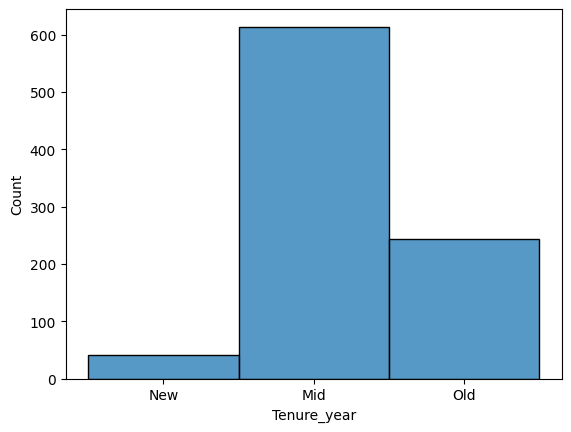

In [9]:
sns.histplot(df['Tenure_year'])

This shows that we a lot of customers who have stayed with for long time and very good numbers of mid tenure customers. but in category of New customer we are only having 42 with is by very low form other 2.

Now we will be understand which feature is most connected to dataset to understand and make better intraction and relationship based feature.

In [10]:
df.groupby('Years')['Churn'].sum().sort_values(ascending=False).head(20)

Years
5.86    3
5.98    3
5.16    2
4.64    2
7.39    2
7.25    2
6.01    2
6.46    2
6.78    2
6.20    2
5.79    2
4.86    2
4.92    2
5.04    2
5.51    2
5.29    2
5.59    2
5.70    2
7.84    1
8.97    1
Name: Churn, dtype: int64

In [11]:
df.groupby('Num_Sites')['Churn'].sum().sort_values(ascending=False).head(20)

Num_Sites
11.0    46
10.0    34
12.0    27
9.0     19
13.0     8
8.0      8
14.0     5
7.0      2
6.0      1
5.0      0
3.0      0
4.0      0
Name: Churn, dtype: int64

year and Num_sites clearly tells us that. 4 to 7 customers are more churned. which the category of mid. if we can make use both of them for intraction features. we will be able to make a stronger feature.

<Axes: xlabel='Years_x_Num_Sites', ylabel='Count'>

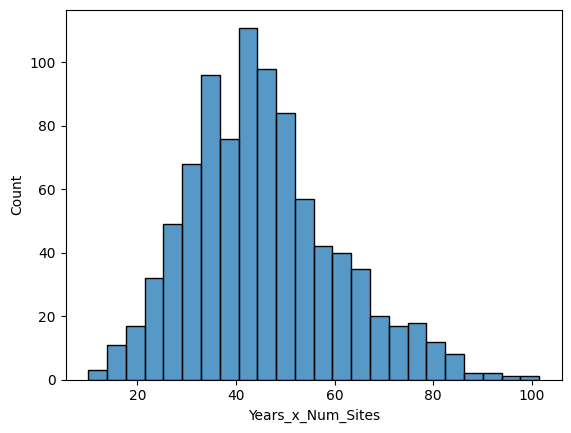

In [12]:
df['Years_x_Num_Sites'] = df['Years'] * df['Num_Sites']

sns.histplot(df['Years_x_Num_Sites'])

In [13]:
df.head(1)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_year,Years_x_Num_Sites
0,Cameron Williams,42.0,11066.8,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old,57.76


Next we will be looking at Total_purchase. and as we can see that these are very big and heavy numbers that can effect the maching to do a proper learning and the efficieny will be highly impacted. so for this we are going to use the transformation featuring.

<Axes: xlabel='Total_Purchase', ylabel='Count'>

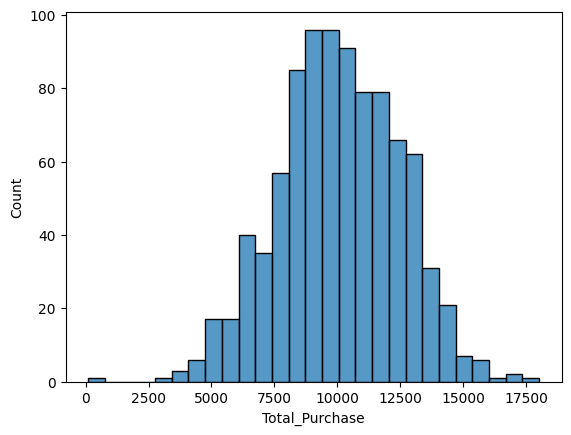

In [14]:
sns.histplot(df['Total_Purchase'])

<Axes: xlabel='Log_Total_Purchase', ylabel='Count'>

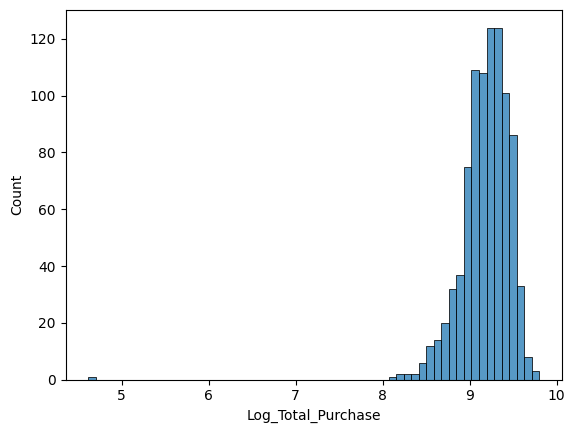

In [15]:
df['Log_Total_Purchase'] = np.log1p(df['Total_Purchase'])

sns.histplot(df['Log_Total_Purchase'])

transformation featuring was successfull but we have come accross as a new problem. the problem of outlier. we need to identify this outlier and check if this is some kind of error or mistake and remove it if requried. because these small details can play big games in machine learning.

In [16]:
df.sort_values(by='Log_Total_Purchase', ascending=True)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_year,Years_x_Num_Sites,Log_Total_Purchase
659,Kayla Reeves,38.0,100.00,0,5.27,5.0,2006-03-10 09:01:48,"1511 Porter Drive Amberberg, NC 44608",Stewart-Lopez,0,Mid,26.35,4.615121
371,Justin Campos,53.0,3263.00,1,2.77,9.0,2013-11-11 22:49:58,"3483 Davis Viaduct Guzmanmouth, RI 60858",Hall-Butler,0,New,24.93,8.090709
448,Lori Medina,39.0,3676.68,1,3.52,9.0,2008-07-16 11:36:45,"PSC 1874, Box 9238 APO AP 68299","Garcia, Hansen and Austin",0,Mid,31.68,8.210037
229,Kelly Terry,45.0,3689.95,1,5.01,11.0,2014-09-10 10:05:06,"3798 Johnson Gardens Hughesside, PR 65467","Ellis, Johnston and Sullivan",0,Mid,55.11,8.213639
777,Kathleen Marquez,35.0,3825.70,0,4.28,8.0,2006-05-15 18:02:51,"984 Gallagher Circle Port Gregorytown, MD 59029","Steele, Nguyen and Lewis",0,Mid,34.24,8.249758
...,...,...,...,...,...,...,...,...,...,...,...,...,...
467,Holly Flores,47.0,15878.11,1,2.05,8.0,2012-05-21 12:56:15,"37362 Anthony Corner Suite 462 Port Saraton, N...",Reyes-Crawford,0,New,16.40,9.672760
818,Eric Terry,42.0,16371.42,1,3.84,10.0,2014-12-18 16:51:16,2384 Lucero Trafficway Suite 201 Campbellchest...,White-Thomas,0,Mid,38.40,9.703353
41,Jason Jones MD,55.0,16838.94,1,6.66,8.0,2007-05-10 15:48:38,"52454 Jessica Passage Apt. 097 Mitchellburgh, ...",Brown-Richardson,1,Old,53.28,9.731509
770,Kevin Powell,43.0,16955.76,0,7.04,8.0,2007-11-14 07:55:14,"33165 Joshua Streets Suite 299 Josephchester, ...",Carroll Ltd,0,Old,56.32,9.738422


we found the outlier

659	Kayla Reeves	38.0	100.00	0	5.27	5.0	2006-03-10 09:01:48	1511 Porter Drive Amberberg, NC 44608	Stewart-Lopez	0	Mid	26.35	4.61512

but we are not going to jump straight into it.

we will see how its impacting the dataset.

In [17]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn,Years_x_Num_Sites,Log_Total_Purchase
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-16 22:35:36.358888,0.166667,45.400711,9.181865
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000,10.000000,4.615121
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-06-29 16:05:08,0.000000,34.930000,9.047600
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-26 09:29:36.500000,0.000000,43.910000,9.215016
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-24 19:50:14.750000,0.000000,53.470000,9.372553
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000,101.500000,9.799626
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885,15.084907,0.298455


it is effecting greatly. so we need to remove it.

In [18]:
df = df.drop(659)

In [19]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn,Years_x_Num_Sites,Log_Total_Purchase
count,899.000000,899.000000,899.000000,899.000000,899.000000,899,899.000000,899.000000,899.000000
mean,41.820912,10073.906151,0.481646,5.273159,8.591769,2011-04-19 00:20:37.614015,0.166852,45.421902,9.186944
min,22.000000,3263.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000,10.000000,8.090709
25%,38.000000,8508.135000,0.000000,4.450000,7.000000,2008-07-01 19:32:54.500000,0.000000,34.965000,9.048895
50%,42.000000,10050.610000,0.000000,5.210000,8.000000,2011-03-28 01:58:13,0.000000,43.920000,9.215488
75%,46.000000,11761.520000,1.000000,6.110000,10.000000,2014-02-24 22:13:10.500000,0.000000,53.480000,9.372673
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000,101.500000,9.799626
std,6.129647,2386.917245,0.499941,1.275158,1.761750,NaN,0.373051,15.079895,0.256758


In [20]:
df.sort_values(by='Total_Purchase', ascending=True).head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_year,Years_x_Num_Sites,Log_Total_Purchase
371,Justin Campos,53.0,3263.00,1,2.77,9.0,2013-11-11 22:49:58,"3483 Davis Viaduct Guzmanmouth, RI 60858",Hall-Butler,0,New,24.93,8.090709
448,Lori Medina,39.0,3676.68,1,3.52,9.0,2008-07-16 11:36:45,"PSC 1874, Box 9238 APO AP 68299","Garcia, Hansen and Austin",0,Mid,31.68,8.210037
229,Kelly Terry,45.0,3689.95,1,5.01,11.0,2014-09-10 10:05:06,"3798 Johnson Gardens Hughesside, PR 65467","Ellis, Johnston and Sullivan",0,Mid,55.11,8.213639


<Axes: xlabel='Years', ylabel='Count'>

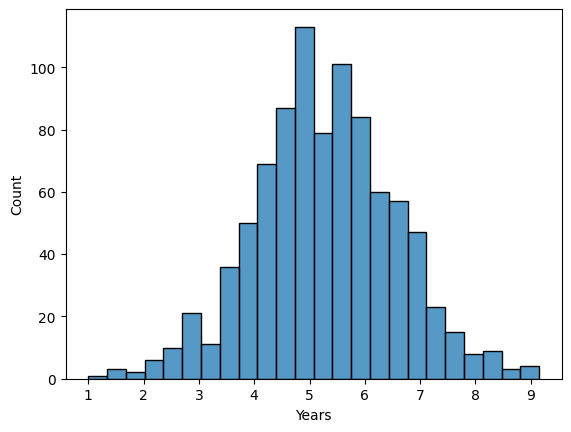

In [21]:
sns.histplot(df['Years'])

<Axes: xlabel='Years', ylabel='Count'>

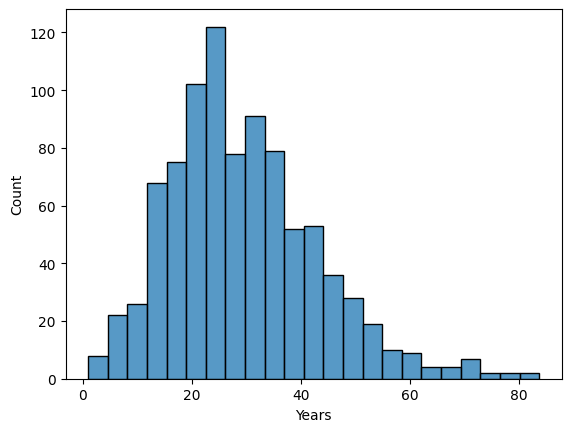

In [22]:
sns.histplot(df['Years'] ** 2)

we can do polynomial featuring on years. as it will help the machine in learning in linear curve then non linear ranges. but i do find Years very much balanced and I would like to go with it.

Since this dataset is cleaned and now we can save this file for furture use and start directly from Feature and target splitting, training and testing.

In [23]:
print('Shape of the dataset: ', df.shape)
print('Null values: ', df.isnull().sum().sum())
print('Duplicated values: ', df.duplicated().sum())

Shape of the dataset:  (899, 13)
Null values:  0
Duplicated values:  0


In [24]:
df.to_csv('../data/cleaned_customer_churn.csv')

Data is cleaned and ready to be trained and tested. lets start with splitting features and target.

In [25]:
df.head(1)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,Tenure_year,Years_x_Num_Sites,Log_Total_Purchase
0,Cameron Williams,42.0,11066.8,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,Old,57.76,9.311795


In [26]:
X = df.drop('Churn', axis=1)

y = df['Churn']

print('Shape of X: ', X.shape)
print('Shape of y: ', y.shape)


Shape of X:  (899, 12)
Shape of y:  (899,)


lets start with the numeric and categorical features.

In [27]:
X.dtypes

Names                            str
Age                          float64
Total_Purchase               float64
Account_Manager                int64
Years                        float64
Num_Sites                    float64
Onboard_date          datetime64[us]
Location                         str
Company                          str
Tenure_year                 category
Years_x_Num_Sites            float64
Log_Total_Purchase           float64
dtype: object

In [28]:
numeric_feature = X.select_dtypes(
    include=['int64','float64']
).columns

categorical_feature = ['Account_Manager', 'Tenure_year' ]

Now lets make the preprocessor for the pipeline.

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder)

In [30]:
prepro = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_feature),
        ('cat', OneHotEncoder(drop='if_binary'), categorical_feature)
    ]
)

Now we will be make the pipeline for the Logistic regression.

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [32]:
LRpp = Pipeline([
    ('preprocessor',  prepro),
    ('model', LogisticRegression())
])

now we will split the X and y to training and testing set

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=.20, random_state=42
)

In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(719, 12)
(180, 12)
(719,)
(180,)


In [36]:
LRpp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [37]:
pred_LR = LRpp.predict(X_test)

now we will be check the classification report

In [38]:
from sklearn.metrics import classification_report

print('Classification report for Logistic regression: \n', classification_report(y_test, pred_LR))

Classification report for Logistic regression: 
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       148
           1       0.76      0.59      0.67        32

    accuracy                           0.89       180
   macro avg       0.84      0.78      0.80       180
weighted avg       0.89      0.89      0.89       180



now we will be checking the cross validation score

In [39]:
from sklearn.model_selection import cross_val_score

In [40]:
LRcvs = cross_val_score(
    LRpp,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print('cross_val_score for Linear Regression: ', LRcvs)

cross_val_score for Linear Regression:  [0.56521739 0.625      0.45833333 0.625      0.52173913]


Now we will do Random forest classifier

In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
rfpp = Pipeline([
    ('preprocessor', prepro),
    ('model', RandomForestClassifier(random_state=42))
])

In [43]:
rfpp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [44]:
pred_rf = rfpp.predict(X_test)

In [45]:
print('Classification report for Random Forest Classifier: ', classification_report(y_test, pred_rf))


Classification report for Random Forest Classifier:                precision    recall  f1-score   support

           0       0.88      0.97      0.92       148
           1       0.72      0.41      0.52        32

    accuracy                           0.87       180
   macro avg       0.80      0.69      0.72       180
weighted avg       0.85      0.87      0.85       180



In [46]:
rfcvs = cross_val_score(
    rfpp,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print('cross_val_score for Randon Forest classifier: ', rfcvs)

cross_val_score for Randon Forest classifier:  [0.52173913 0.58333333 0.41666667 0.5        0.47826087]


Now we will be doing Gradient Boosting classifier

In [47]:
from sklearn.ensemble import GradientBoostingClassifier

In [48]:
GBCpp = Pipeline([
    ('preprocessor', prepro),
    ('model', GradientBoostingClassifier(random_state=42) )
])

In [49]:
GBCpp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [50]:
pred_GBC = GBCpp.predict(X_test)

In [51]:
print('classification_report for GBC: ', classification_report(y_test, pred_GBC))

classification_report for GBC:                precision    recall  f1-score   support

           0       0.90      0.96      0.93       148
           1       0.74      0.53      0.62        32

    accuracy                           0.88       180
   macro avg       0.82      0.75      0.77       180
weighted avg       0.88      0.88      0.88       180



In [52]:
GBCcvs = cross_val_score(
    GBCpp,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print('cross_val_score for GBC: ',  GBCcvs)

cross_val_score for GBC:  [0.60869565 0.58333333 0.41666667 0.5        0.52173913]


now we will be doing KNN

In [53]:
from sklearn.neighbors import KNeighborsClassifier

In [54]:
knnpp = Pipeline([
    ('preprocessor', prepro),
    ('model', KNeighborsClassifier())
])

In [55]:
knnpp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [56]:
pred_knn = knnpp.predict(X_test)

In [57]:
print('classification_report for KNN Classifier: ', classification_report(y_test, pred_knn))

classification_report for KNN Classifier:                precision    recall  f1-score   support

           0       0.86      0.95      0.90       148
           1       0.53      0.28      0.37        32

    accuracy                           0.83       180
   macro avg       0.69      0.61      0.63       180
weighted avg       0.80      0.83      0.81       180



In [58]:
knncvs = cross_val_score(
    knnpp,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)


print('cross_val_score for Knn Classifier: ', knncvs)

cross_val_score for Knn Classifier:  [0.52173913 0.33333333 0.5        0.5        0.60869565]


now we will be doing for XGBOOST

In [59]:
from xgboost import XGBClassifier

In [60]:
XGBpp = Pipeline([
    ('preprocessor', prepro),
    ('model', XGBClassifier(
        random_state =42,
        eval_metric = 'logloss'
        ))
])

In [61]:
XGBpp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [62]:
pred_XGB = XGBpp.predict(X_test)

In [63]:
print('classification_report for XGBoost: ', classification_report(y_test, pred_XGB))

classification_report for XGBoost:                precision    recall  f1-score   support

           0       0.88      0.93      0.91       148
           1       0.58      0.44      0.50        32

    accuracy                           0.84       180
   macro avg       0.73      0.68      0.70       180
weighted avg       0.83      0.84      0.84       180



In [64]:
xgbcvs = cross_val_score(
    XGBpp,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print('cross_val_score for XGBoost: ', xgbcvs)

cross_val_score for XGBoost:  [0.52173913 0.70833333 0.45833333 0.54166667 0.56521739]


In [65]:
print('cross_val_score for Linear Regression:\n ', LRcvs)
print('\ncross_val_score for Randon Forest classifier:\n ', rfcvs)
print('\ncross_val_score for GBC:\n ',  GBCcvs)
print('\ncross_val_score for Knn Classifier:\n ', knncvs)
print('\ncross_val_score for XGBoost: \n', xgbcvs)

cross_val_score for Linear Regression:
  [0.56521739 0.625      0.45833333 0.625      0.52173913]

cross_val_score for Randon Forest classifier:
  [0.52173913 0.58333333 0.41666667 0.5        0.47826087]

cross_val_score for GBC:
  [0.60869565 0.58333333 0.41666667 0.5        0.52173913]

cross_val_score for Knn Classifier:
  [0.52173913 0.33333333 0.5        0.5        0.60869565]

cross_val_score for XGBoost: 
 [0.52173913 0.70833333 0.45833333 0.54166667 0.56521739]


In [68]:
from lightgbm import LGBMClassifier

In [69]:
lgbm_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', LGBMClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1
    ))
])

In [70]:
lgbm_pp.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 118, number of negative: 601
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1008
[LightGBM] [Info] Number of data points in the train set: 719, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.164117 -> initscore=-1.627910
[LightGBM] [Info] Start training from score -1.627910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [72]:
lgbm_pred = lgbm_pp.predict(X_test)

d:\advanced-data-wrangling-lab\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, lgbm_pred))
print("Precision:", precision_score(y_test, lgbm_pred))
print("Recall   :", recall_score(y_test, lgbm_pred))
print("F1 Score :", f1_score(y_test, lgbm_pred))

print(classification_report(y_test, lgbm_pred))

Accuracy : 0.85
Precision: 0.5925925925925926
Recall   : 0.5
F1 Score : 0.5423728813559322
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       148
           1       0.59      0.50      0.54        32

    accuracy                           0.85       180
   macro avg       0.74      0.71      0.73       180
weighted avg       0.84      0.85      0.84       180



In [77]:
from catboost import CatBoostClassifier

In [78]:
cat_pp = Pipeline([
    ('preprocessor', prepro),
    ('model', CatBoostClassifier(
        random_state=42,
        iterations=100,
        learning_rate=0.1,
        verbose=0
    ))
])

In [79]:
cat_pp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [80]:
cat_pred = cat_pp.predict(X_test)

In [81]:
print("Accuracy :", accuracy_score(y_test, cat_pred))
print("Precision:", precision_score(y_test, cat_pred))
print("Recall   :", recall_score(y_test, cat_pred))
print("F1 Score :", f1_score(y_test, cat_pred))

print(classification_report(y_test, cat_pred))

Accuracy : 0.8611111111111112
Precision: 0.6666666666666666
Recall   : 0.4375
F1 Score : 0.5283018867924528
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       148
           1       0.67      0.44      0.53        32

    accuracy                           0.86       180
   macro avg       0.78      0.70      0.72       180
weighted avg       0.85      0.86      0.85       180



In [82]:
CRcall = pd.DataFrame({
    'Model' : ['Logistic regression', 'RandomForestClassifier', 'GradientBoostingClassifier', 'KNeighborsClassifier', 'xgBoost','LGBMClassifier','CatBoostClassifier'],
    'Recall_score' : [0.59,0.41, 0.53,  0.28, 0.44, 0.50,  0.44 ]
})

In [83]:
CRcall.sort_values('Recall_score', ascending=False)

,Model,Recall_score
0,Logistic regression,0.59
2,GradientBoostingClassifier,0.53
5,LGBMClassifier,0.50
6,CatBoostClassifier,0.44
4,xgBoost,0.44
1,RandomForestClassifier,0.41
3,KNeighborsClassifier,0.28
